# Gestión y transformación de datos

En el presente Notebook se busca desarrollar el proceso de *ETL* (Extract, Transform and Load) el cual es un proceso fundamental en ingeniería de datos que combina información de múltiples fuentes de un almacén de datos centralizado (Data Warehouse).

Este proceso permite limpiar, organizar y estandarizar datos para mejorar el análisis y la toma de decisiones empresariales, siendo la base de la inteligencia empresarial.

In [20]:
import numpy as numpy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

---
## Importación de la base de datos

In [121]:
# Definimos la URL del repositorio en GitHub desde el cual se van a leer los datos.
url = 'https://raw.githubusercontent.com/Jero2110/Big_Data_Phase03/refs/heads/main/analisis/data/Anexo%201%20-%20Dataset1.csv'

try:
    # Intentamos leer el archivo con la URL entregada
    #  Para este caso, se determina un encoding 'latin1' con el fin de evitar inconvenientes
    #  con posibles caracteres no disponibles en UTF-8 que generen inconvenientes para cargar los datos
    df = pd.read_csv(url, encoding='latin1')
    
    # Verificamos que se haya leído correctamente
    print("---"*30)
    print("Archivo cargado con éxito")
    print("---"*30)
    print(f"Dimensiones: {df.shape[0]} filas y {df.shape[1]} columnas.")
    
    # Mostramos una vista previa de los datos
    display(df.head()) 

except Exception as e:
    # En caso de presentarse cualquier error, el programa se detiene y se dan detalles del error generado
    print("---"*30)
    print("Error al cargar el archivo.")
    print("---"*30)
    print(f"Detalle técnico:\n{e}")


------------------------------------------------------------------------------------------
Archivo cargado con éxito
------------------------------------------------------------------------------------------
Dimensiones: 541909 filas y 8 columnas.


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


---
## Contextualización de los datos

In [122]:
# Con el fin de conocer los tipos de datos disponibles en los registros cargados, ejecutamos el siguiente código
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [123]:
# Para mejorar la comprensión de los datos, se traducen los encabezados de las columnas del inglés al español 
#  Sin embargo, esto se realiza teniendo en cuenta que se trata de un ejercicio práctico, ya que al realizar esto
#  se puede llegar a generar una pérdida en la conexión de las posibles claves foráneas que existan en la base de datos
#  extraída. Lo cual implica que esta revisión quedaría desconcetada para la automatización y réplica de la información
df = df.rename(columns={'InvoiceNo': 'Nro_Factura',
                        'StockCode': 'Cod_Inventario',
                        'Description': 'Descripción',
                        'Quantity': 'Cantidad',
                        'InvoiceDate': 'Fecha_factura',
                        'UnitPrice': 'Precio_Unitario',
                        'CustomerID': 'ID_Cliente',
                        'Country': 'País'})

# Verificamos que se hayan cambiado los nombres de las columnas
print(f'Los nombres de las columnas son:\n{df.columns}')


Los nombres de las columnas son:
Index(['Nro_Factura', 'Cod_Inventario', 'Descripción', 'Cantidad',
       'Fecha_factura', 'Precio_Unitario', 'ID_Cliente', 'País'],
      dtype='object')


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Nro_Factura      541909 non-null  object 
 1   Cod_Inventario   541909 non-null  object 
 2   Descripción      540455 non-null  object 
 3   Cantidad         541909 non-null  int64  
 4   Fecha_factura    541909 non-null  object 
 5   Precio_Unitario  541909 non-null  float64
 6   ID_Cliente       406829 non-null  float64
 7   País             541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


---
## Transformación de datos

Teniendo en cuenta los tipos de datos almacenados en cada campo, se realizarán las transformaciones necesarias para preparar los datos para futuros análisis. Inicialmente, se dejará la columna número de factura en formato texto debido a que este campo puede contener números en la mayor parte de la información, pero puede contener letras dentro del número asignado. Por otra parte, debido a que el código de inventario (Cod_Inventario) puede contener texto, como se observa en las primeras líneas del DataFrame, se dejará como tipo texto; así mismo con la descripción y el país.

Por otra parte, la cantidad se dejará en formato entero, teniendo en cuenta que se puede tratar de productos enteros y no medidos o pesados donde se puede requerir de decimales. Por otra parte, el precio unitario se dejará en el tipo de dato flotante teniendo en cuenta que puede contener decimales importantes que no se pueden retirar en este punto del análisis.

Finalmente, se convertirá la fecha en tipo DateTime con el fin de facilitar futuros análisis que requieran de la agrupación de la información por fechas de ventas. Por otro lado, se convertirá el identificador del cliente en tipo texto (string) para facilitar su consulta.

### Conversiones

In [132]:
# Conversiones a fecha (DateTime)
df['Fecha_factura'] = pd.to_datetime(df['Fecha_factura'], errors='coerce')

# Conversiones a texto (String)
df['ID_Cliente'] = df['ID_Cliente'].astype(str).replace('nan', '')

# Revisamos si las conversiones se realizaron adecuadamente
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   Nro_Factura      541909 non-null  object        
 1   Cod_Inventario   541909 non-null  object        
 2   Descripción      540455 non-null  object        
 3   Cantidad         541909 non-null  int64         
 4   Fecha_factura    541909 non-null  datetime64[ns]
 5   Precio_Unitario  541909 non-null  float64       
 6   ID_Cliente       541909 non-null  object        
 7   País             541909 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 33.1+ MB


### Limpieza de datos

------------------------------------------------------------------------------------------
Análisis descriptivo de las variables numéricas
------------------------------------------------------------------------------------------
            Cantidad  Precio_Unitario
count  541909.000000    541909.000000
mean        9.552250         4.611114
std       218.081158        96.759853
min    -80995.000000    -11062.060000
25%         1.000000         1.250000
50%         3.000000         2.080000
75%        10.000000         4.130000
max     80995.000000     38970.000000


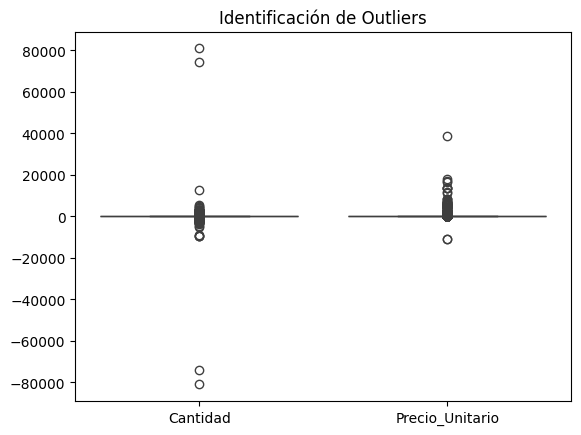

In [53]:
# Para el caso de las varaibles numéricas se identificarán las condiciones del dataset por medio de
#  estadísticas descriptivas como el valor mínimo, máximo, promedio y cuartiles. Así como la visualización de los
#  datos por medio de gráficos de dispersión

# Análisis con estadísticas descriptivas
print("---"*30)
print('Análisis descriptivo de las variables numéricas')
print("---"*30)

print(df.select_dtypes(include=['number']).describe())

# Análisis visual

sns.boxplot(data=df[['Cantidad','Precio_Unitario']])
plt.title('Identificación de Outliers')
plt.show()

In [64]:
# Observando los resultados obtenidos, podemos decir que se deben de eliminar los registros donde se presenten
#  condiciones como:
#  1. Cantidades y precios unitarios negativos.

df[(df['Cantidad']<=-60000)]

,Nro_Factura,Cod_Inventario,Descripción,Cantidad,Fecha_factura,Precio_Unitario,ID_Cliente,País
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.04,12346.0,United Kingdom
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2.08,16446.0,United Kingdom


In [65]:
df[df['Descripción']=='MEDIUM CERAMIC TOP STORAGE JAR']

,Nro_Factura,Cod_Inventario,Descripción,Cantidad,Fecha_factura,Precio_Unitario,ID_Cliente,País
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.04,12346.0,United Kingdom
186770,552882,23166,MEDIUM CERAMIC TOP STORAGE JAR,96,2011-05-12 10:10:00,1.04,14646.0,Netherlands
187196,552953,23166,MEDIUM CERAMIC TOP STORAGE JAR,4,2011-05-12 12:11:00,1.25,16745.0,United Kingdom
187718,553005,23166,MEDIUM CERAMIC TOP STORAGE JAR,5,2011-05-12 16:29:00,1.25,14651.0,United Kingdom
...,...,...,...,...,...,...,...,...
533742,581108,23166,MEDIUM CERAMIC TOP STORAGE JAR,2,2011-12-07 12:16:00,1.25,15984.0,United Kingdom
536248,581219,23166,MEDIUM CERAMIC TOP STORAGE JAR,1,2011-12-08 09:28:00,2.46,nan,United Kingdom
539776,581439,23166,MEDIUM CERAMIC TOP STORAGE JAR,2,2011-12-08 16:30:00,2.46,nan,United Kingdom
540301,581476,23166,MEDIUM CERAMIC TOP STORAGE JAR,48,2011-12-09 08:48:00,1.04,12433.0,Norway


Frecuencia de casos especiales:
  Letra  Frecuencia
0     M         571
1     D          77
2     S          63
3     B           3
4     m           1


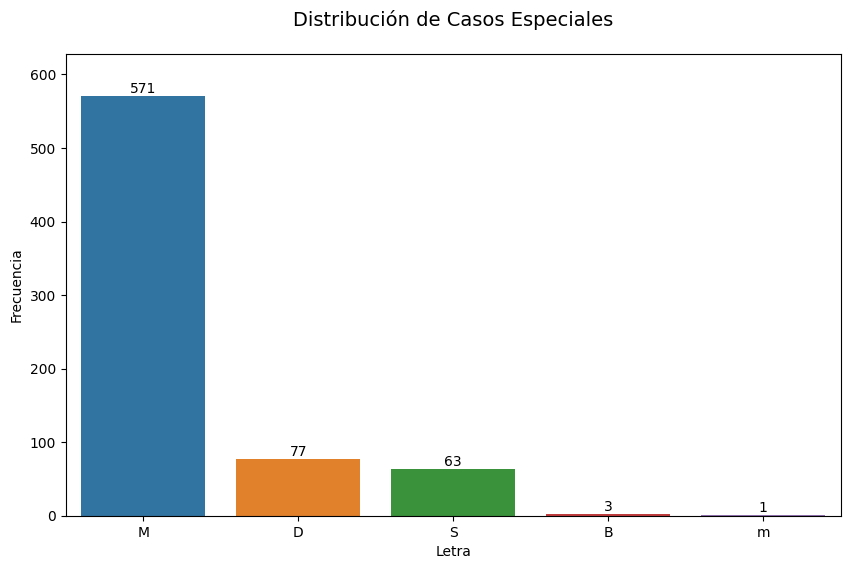

In [95]:
codigos = df[df['Cod_Inventario'].str.len() == 1]

codigos_especiales = codigos['Cod_Inventario'].str.strip().value_counts().reset_index()
codigos_especiales.columns = ['Letra', 'Frecuencia']

print("Frecuencia de casos especiales:")
print(codigos_especiales)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=codigos_especiales, x='Letra', y='Frecuencia', hue='Letra', legend=False)

for container in ax.containers:
    ax.bar_label(container)

plt.title('Distribución de Casos Especiales', fontsize=14, pad=20)
plt.ylim(0, codigos_especiales['Frecuencia'].max() * 1.1)
plt.show()

In [101]:
# Agrupa por letra y junta las descripciones únicas en una lista
descripciones_por_letra = codigos.groupby('Cod_Inventario')['Descripción'].unique()

print(descripciones_por_letra)


Cod_Inventario
B    [Adjust bad debt]
D           [Discount]
M             [Manual]
S            [SAMPLES]
m             [Manual]
Name: Descripción, dtype: object


In [136]:
df[df['ID_Cliente'] == '']

,Nro_Factura,Cod_Inventario,Descripción,Cantidad,Fecha_factura,Precio_Unitario,ID_Cliente,País
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,,United Kingdom
...,...,...,...,...,...,...,...,...
541536,581498,85099B,JUMBO BAG RED RETROSPOT,5,2011-12-09 10:26:00,4.13,,United Kingdom
541537,581498,85099C,JUMBO BAG BAROQUE BLACK WHITE,4,2011-12-09 10:26:00,4.13,,United Kingdom
541538,581498,85150,LADIES & GENTLEMEN METAL SIGN,1,2011-12-09 10:26:00,4.96,,United Kingdom
541539,581498,85174,S/4 CACTI CANDLES,1,2011-12-09 10:26:00,10.79,,United Kingdom


In [118]:
df[df['ID_Cliente']=='nan']

,Nro_Factura,Cod_Inventario,Descripción,Cantidad,Fecha_factura,Precio_Unitario,ID_Cliente,País
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,nan,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,nan,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,nan,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,nan,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,nan,United Kingdom
...,...,...,...,...,...,...,...,...
541536,581498,85099B,JUMBO BAG RED RETROSPOT,5,2011-12-09 10:26:00,4.13,nan,United Kingdom
541537,581498,85099C,JUMBO BAG BAROQUE BLACK WHITE,4,2011-12-09 10:26:00,4.13,nan,United Kingdom
541538,581498,85150,LADIES & GENTLEMEN METAL SIGN,1,2011-12-09 10:26:00,4.96,nan,United Kingdom
541539,581498,85174,S/4 CACTI CANDLES,1,2011-12-09 10:26:00,10.79,nan,United Kingdom
